# Understanding the effects of Noise in Quantum Computing

**Author**: Dr. Ritajit Majumdar, IBM Quantum, IBM India Research Lab 

*&copy; Feel free to reuse this notebook with due credit*

## Learning Objectives

In this notebook, you will explore how different types of quantum noise affect the performance of quantum algorithms. Specifically, you will:

- Understand how **readout errors** corrupt measurement outcomes and impact energy estimation
- Analyze the effects of **depolarizing noise** on quantum gate operations
- Investigate how **thermal relaxation** degrades quantum states over time
- Quantify the relationship between noise levels and algorithm performance
- Compare the relative impact of different noise sources on quantum computations

We will use the Variational Quantum Eigensolver (VQE) algorithm as a testbed to observe these noise effects in action. By the end of this notebook, you will have a practical understanding of how real quantum hardware limitations affect computational results.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error, ReadoutError
from qiskit_ibm_runtime import EstimatorV2 as Estimator, QiskitRuntimeService, Batch
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from scipy.optimize import minimize, curve_fit

# Set random seed for reproducibility
np.random.seed(42)
seed_estimator = 123

## Section 1: Ground State Energy by Exact Diagonalization

We begin by establishing the theoretical ground truth. We construct a 6-qubit quantum circuit using the `EfficientSU2` ansatz and define our observable as the average of the Pauli-Z operator on each qubit:

$$H = \frac{1}{6}\sum_{i=0}^{5} Z_i$$

By exact diagonalization, we can compute the true ground state energy without any approximations or noise.

In [2]:
# Define the number of qubits
num_qubits = 6

# Create the EfficientSU2 ansatz
ansatz = efficient_su2(num_qubits, reps=1, entanglement='linear')

# Define the observable: average of Z on each qubit
pauli_strings = [f"{'I' * i}Z{'I' * (num_qubits - i - 1)}" for i in range(num_qubits)]
coeffs = [1.0 / num_qubits] * num_qubits
observable = SparsePauliOp(pauli_strings, coeffs)

print(f"Observable: {observable}")
num_params = ansatz.num_parameters
print(f"\nNumber of parameters in ansatz: {num_params}")

Observable: SparsePauliOp(['ZIIIII', 'IZIIII', 'IIZIII', 'IIIZII', 'IIIIZI', 'IIIIIZ'],
              coeffs=[0.16666667+0.j, 0.16666667+0.j, 0.16666667+0.j, 0.16666667+0.j,
 0.16666667+0.j, 0.16666667+0.j])

Number of parameters in ansatz: 24


In [3]:
# Compute ground state energy by exact diagonalization
observable_matrix = observable.to_matrix()
eigenvalues = np.linalg.eigvalsh(observable_matrix)
ground_state_energy = np.min(eigenvalues)

print(f"Ground State Energy (Exact): {ground_state_energy:.6f}")

Ground State Energy (Exact): -1.000000


## Section 2: VQE on Ideal Simulator

Next, we implement VQE using an ideal quantum simulator without any noise. This serves as our baseline for comparison. We will observe how the energy estimate converges to the ground state energy through iterative optimization.

The VQE algorithm optimizes the circuit parameters $\theta$ to minimize the expectation value:

$$E(\theta) = \langle \psi(\theta) | H | \psi(\theta) \rangle$$

Transpiled circuit depth: 32
Transpiled circuit gate counts: OrderedDict({'rz': 56, 'sx': 33, 'cz': 5})


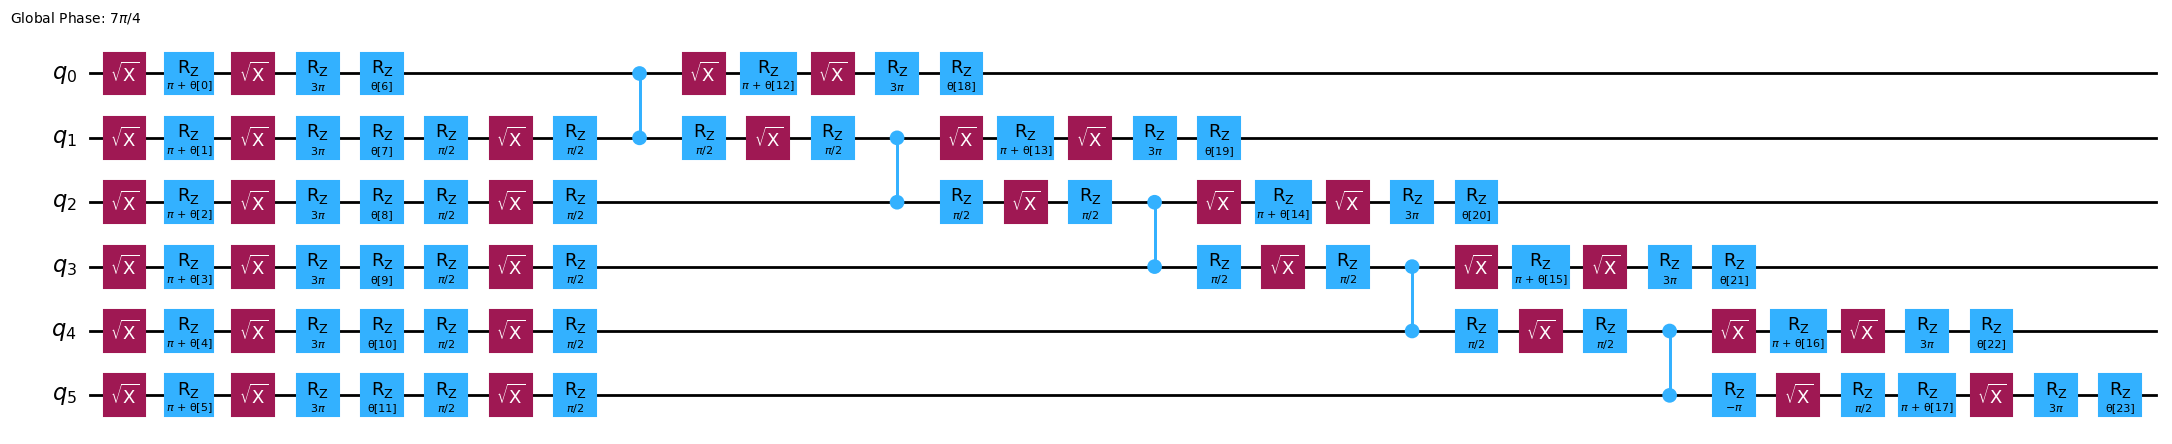

In [4]:
# Transpile the ansatz to basis gates
basis_gates = ['x', 'sx', 'rz', 'cz'] # these are the basis gates of IBM Quantum Heron processor
pm = generate_preset_pass_manager(optimization_level=1, basis_gates=basis_gates)
transpiled_ansatz = pm.run(ansatz)

print(f"Transpiled circuit depth: {transpiled_ansatz.depth()}")
print(f"Transpiled circuit gate counts: {transpiled_ansatz.count_ops()}")
display(transpiled_ansatz.draw('mpl', fold=-1))

In [5]:
# Setup ideal simulator
ideal_simulator = AerSimulator()

# Transpile observable
transpiled_observable = observable.apply_layout(transpiled_ansatz.layout)

# Create estimator
ideal_estimator = Estimator(mode=ideal_simulator)
ideal_estimator.options.seed_estimator = seed_estimator

# Store energy values during optimization
ideal_energy_history = []

def cost_function_ideal(params):
    """Cost function for VQE optimization."""
    job = ideal_estimator.run([(transpiled_ansatz, transpiled_observable, params)])
    result = job.result()
    energy = result[0].data.evs
    ideal_energy_history.append(energy)
    return energy

# Initial parameters
initial_params = np.random.uniform(0, 2 * np.pi, num_params)

# Run VQE optimization
print("Running VQE on ideal simulator...")
result_ideal = minimize(cost_function_ideal, initial_params, method='COBYLA')

print(f"\nOptimization completed!")
print(f"Final energy (Ideal): {result_ideal.fun:.6f}")
print(f"Ground state energy (Exact): {ground_state_energy:.6f}")
print(f"Error: {abs(result_ideal.fun - ground_state_energy):.6f}")

Running VQE on ideal simulator...

Optimization completed!
Final energy (Ideal): -0.997314
Ground state energy (Exact): -1.000000
Error: 0.002686


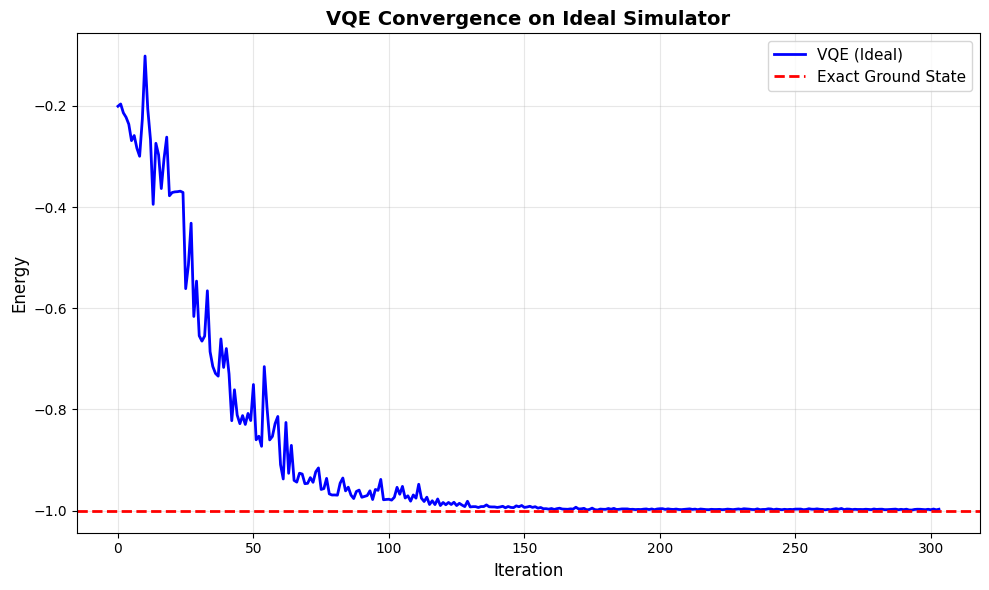

In [6]:
# Plot the convergence
plt.figure(figsize=(10, 6))
plt.plot(ideal_energy_history, 'b-', linewidth=2, label='VQE (Ideal)')
plt.axhline(y=ground_state_energy, color='r', linestyle='--', linewidth=2, label='Exact Ground State')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('VQE Convergence on Ideal Simulator', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 3: Effect of Readout Error

Readout errors occur when the measurement apparatus incorrectly identifies the quantum state. These errors are characterized by:

- **$p_{0|1}$**: Probability of measuring 0 when the true state is 1
- **$p_{1|0}$**: Probability of measuring 1 when the true state is 0

In this section, we assume symmetric readout errors where $p_{0|1} = p_{1|0}$. We will investigate how increasing readout error rates affect the VQE energy estimation.

In [7]:
# Readout error probabilities to test
readout_probs = [0.005, 0.015, 0.025]
readout_energy_histories = {}

for prob in readout_probs:
    print(f"\nRunning VQE with readout error probability: {prob}")
    
    # Create noise model with readout error
    noise_model = NoiseModel()
    
    # Define readout error: p0g1 = p1g0 = prob
    readout_error = ReadoutError([[1 - prob, prob], [prob, 1 - prob]])
    
    # Add readout error to all qubits
    for qubit in range(num_qubits):
        noise_model.add_readout_error(readout_error, [qubit])
    
    # Create noisy simulator
    noisy_simulator = AerSimulator(noise_model=noise_model)
    noisy_estimator = Estimator(mode=noisy_simulator)
    noisy_estimator.options.seed_estimator = seed_estimator
    
    # Store energy values
    energy_history = []
    
    def cost_function_readout(params):
        job = noisy_estimator.run([(transpiled_ansatz, transpiled_observable, params)])
        result = job.result()
        energy = result[0].data.evs
        energy_history.append(energy)
        return energy
    
    # Run optimization
    result = minimize(cost_function_readout, initial_params, method='COBYLA')
    readout_energy_histories[prob] = energy_history
    
    print(f"Final energy: {result.fun:.6f}")

print("\nReadout error analysis completed!")


Running VQE with readout error probability: 0.005
Final energy: -0.982747

Running VQE with readout error probability: 0.015
Final energy: -0.961995

Running VQE with readout error probability: 0.025
Final energy: -0.931071

Readout error analysis completed!


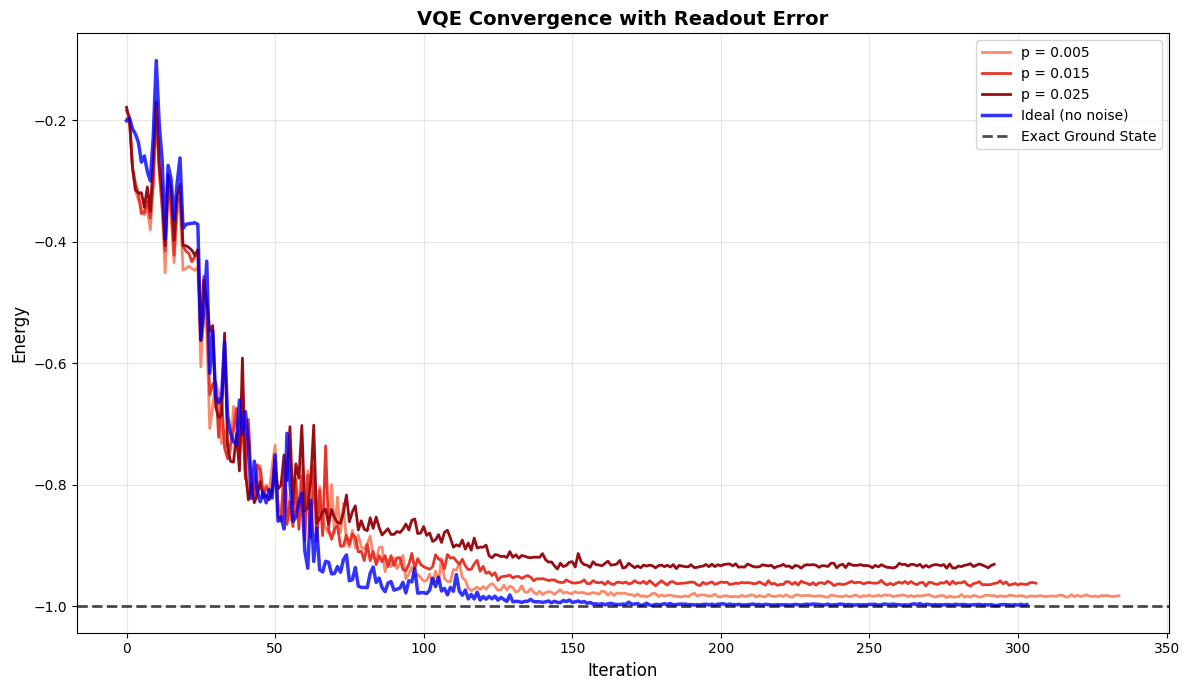

In [8]:
# Plot all readout error cases
plt.figure(figsize=(12, 7))

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(readout_probs)))

for i, prob in enumerate(readout_probs):
    plt.plot(readout_energy_histories[prob], linewidth=2, 
             label=f'p = {prob}', color=colors[i])

plt.plot(ideal_energy_history, 'b-', linewidth=2.5, label='Ideal (no noise)', alpha=0.8)
plt.axhline(y=ground_state_energy, color='k', linestyle='--', linewidth=2, 
            label='Exact Ground State', alpha=0.7)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('VQE Convergence with Readout Error', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Let us zoom in the converged values

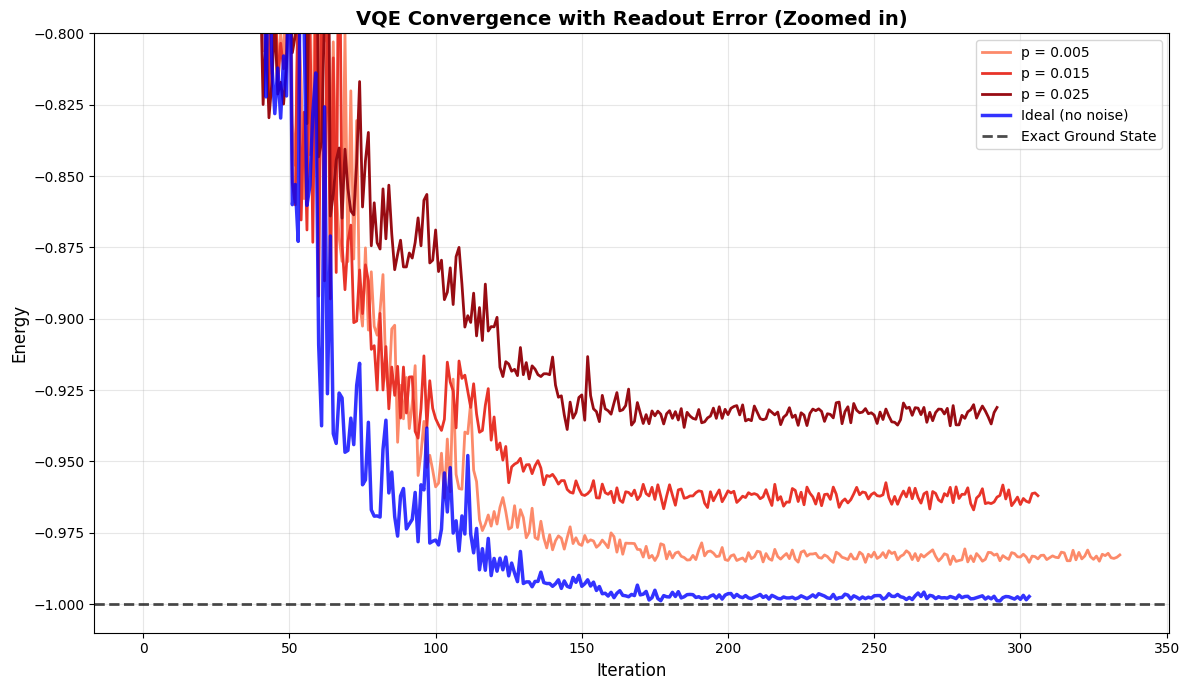

In [9]:
# Plot all readout error cases
plt.figure(figsize=(12, 7))

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(readout_probs)))

for i, prob in enumerate(readout_probs):
    plt.plot(readout_energy_histories[prob], linewidth=2, 
             label=f'p = {prob}', color=colors[i])

plt.plot(ideal_energy_history, 'b-', linewidth=2.5, label='Ideal (no noise)', alpha=0.8)
plt.axhline(y=ground_state_energy, color='k', linestyle='--', linewidth=2, 
            label='Exact Ground State', alpha=0.7)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('VQE Convergence with Readout Error (Zoomed in)', fontsize=14, fontweight='bold')
plt.ylim(-1.01,-0.8)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Do we see some pattern here?

The converged values of the energy for different readout error probability seems to a function of the readout error probability (that is not surprising, right?). But what is the function?

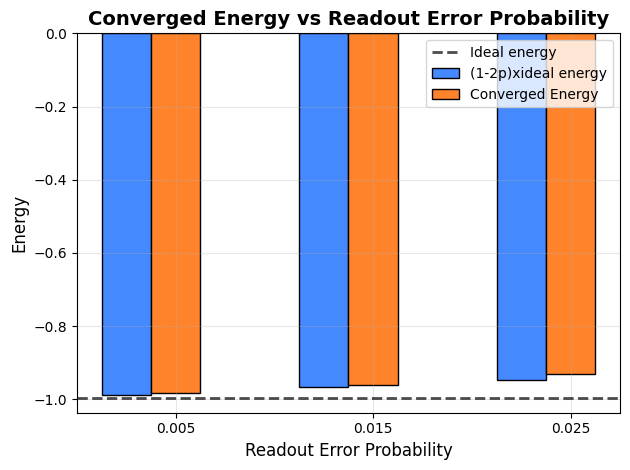

In [15]:
converged_roerror_energies = [float(readout_energy_histories[key][-1]) for key in readout_probs]
converged_ideal_energy = float(ideal_energy_history[-1])
scaling_factors = [(1 - 2*prob)*converged_ideal_energy for prob in readout_probs]

# plot
barWidth = 0.25
br1 = np.arange(len(readout_probs)) 
br2 = [x + barWidth for x in br1]

plt.bar(br1, scaling_factors, width = barWidth, color='#4589ff', edgecolor ='black', label='(1-2p)xideal energy')
plt.bar(br2, converged_roerror_energies, width = barWidth, color='#ff832b', edgecolor ='black', label='Converged Energy')
plt.axhline(y=converged_ideal_energy, color='k', linestyle='--', linewidth=2, 
            label='Ideal energy', alpha=0.7)
plt.xlabel('Readout Error Probability', fontsize=12)
plt.xticks([r + barWidth for r in range(len(readout_probs))], 
        readout_probs)
plt.ylabel('Energy', fontsize=12)
plt.title('Converged Energy vs Readout Error Probability', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### So we should be able to extract the ideal value from the noisy value!

If we understand that the scaling factor is $(1-2p)$, then we can extract the ideal value from the noisy value by dividing the noisy value by $(1-2p)$.

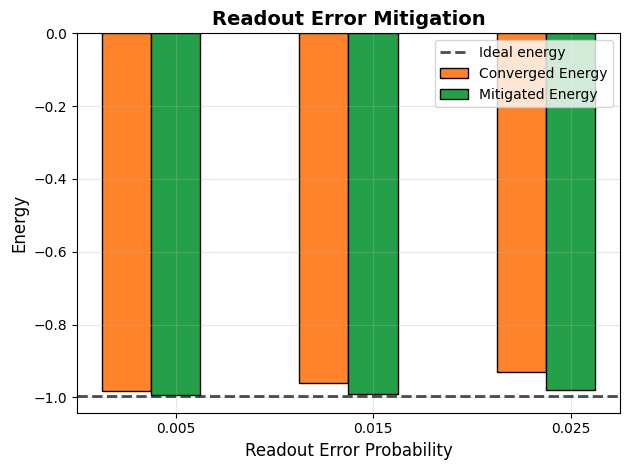

In [14]:
mitigated_roerror_energies = [float(readout_energy_histories[key][-1]) / (1 - 2 * key) 
                            for key in readout_probs]

# plot
barWidth = 0.25
br1 = np.arange(len(readout_probs)) 
br2 = [x + barWidth for x in br1]

plt.bar(br1, converged_roerror_energies, width = barWidth, color='#ff832b', edgecolor ='black', label='Converged Energy')
plt.bar(br2, mitigated_roerror_energies, width = barWidth, color='#24a148', edgecolor ='black', label='Mitigated Energy')
plt.axhline(y=converged_ideal_energy, color='k', linestyle='--', linewidth=2, 
            label='Ideal energy', alpha=0.7)
plt.xlabel('Readout Error Probability', fontsize=12)
plt.xticks([r + barWidth for r in range(len(readout_probs))], 
        readout_probs)
plt.ylabel('Energy', fontsize=12)
plt.title('Readout Error Mitigation', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 4: Effect of Depolarizing Noise

Depolarizing noise is a common model for gate errors where a quantum gate is replaced by a completely random operation with some probability. For a single-qubit gate, the depolarizing channel with error probability $p$ is:

$$\mathcal{E}(\rho) = (1-p)\rho + \frac{p}{3}(X\rho X + Y\rho Y + Z\rho Z)$$

We apply depolarizing errors to all gates except `rz` (which is a virtual gate in many implementations). Single-qubit gates typically have error rates on the order of $10^{-3}$, while two-qubit gates have higher error rates around $10^{-2}$.

In [16]:
# Depolarizing error probabilities
# Format: (single_qubit_error, two_qubit_error)
depolarizing_params = [
    (0.001, 0.01),
    (0.003, 0.02),
    (0.005, 0.03)
]

depolarizing_energy_histories = {}

for sq_error, tq_error in depolarizing_params:
    print(f"\nRunning VQE with depolarizing error: 1Q={sq_error}, 2Q={tq_error}")
    
    # Create noise model
    noise_model = NoiseModel()
    
    # Add depolarizing error to single-qubit gates (x, sx)
    depol_1q = depolarizing_error(sq_error, 1)
    noise_model.add_all_qubit_quantum_error(depol_1q, ['x', 'sx'])
    
    # Add depolarizing error to two-qubit gates (cz)
    depol_2q = depolarizing_error(tq_error, 2)
    noise_model.add_all_qubit_quantum_error(depol_2q, ['cz'])
    
    # Create noisy simulator
    noisy_simulator = AerSimulator(noise_model=noise_model)
    noisy_estimator = Estimator(mode=noisy_simulator)
    noisy_estimator.options.seed_estimator = seed_estimator
    
    # Store energy values
    energy_history = []
    
    def cost_function_depol(params):
        job = noisy_estimator.run([(transpiled_ansatz, transpiled_observable, params)])
        result = job.result()
        energy = result[0].data.evs
        energy_history.append(energy)
        return energy
    
    # Run optimization
    result = minimize(cost_function_depol, initial_params, method='COBYLA')
    depolarizing_energy_histories[(sq_error, tq_error)] = energy_history
    
    print(f"Final energy: {result.fun:.6f}")

print("\nDepolarizing noise analysis completed!")


Running VQE with depolarizing error: 1Q=0.001, 2Q=0.01
Final energy: -0.963216

Running VQE with depolarizing error: 1Q=0.003, 2Q=0.02
Final energy: -0.917725

Running VQE with depolarizing error: 1Q=0.005, 2Q=0.03
Final energy: -0.871501

Depolarizing noise analysis completed!


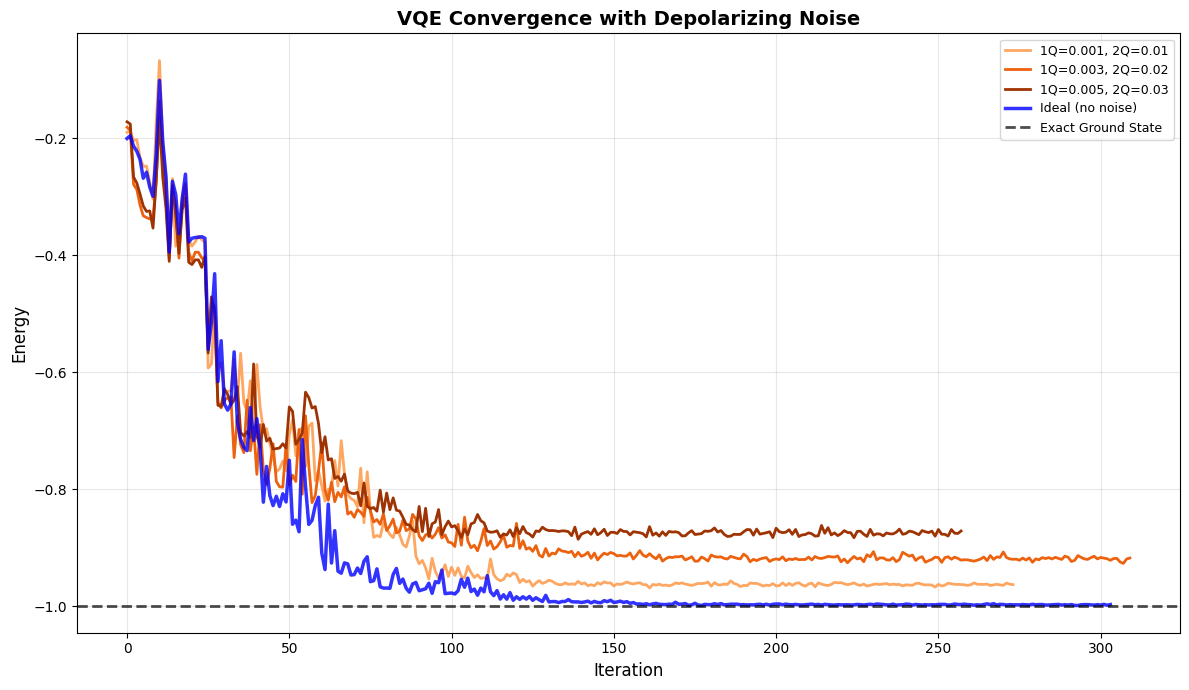

In [17]:
# Plot all depolarizing error cases
plt.figure(figsize=(12, 7))

colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(depolarizing_params)))

for i, (sq_error, tq_error) in enumerate(depolarizing_params):
    plt.plot(depolarizing_energy_histories[(sq_error, tq_error)], linewidth=2,
             label=f'1Q={sq_error}, 2Q={tq_error}', color=colors[i])

plt.plot(ideal_energy_history, 'b-', linewidth=2.5, label='Ideal (no noise)', alpha=0.8)
plt.axhline(y=ground_state_energy, color='k', linestyle='--', linewidth=2,
            label='Exact Ground State', alpha=0.7)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('VQE Convergence with Depolarizing Noise', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5: Effect of Thermal Relaxation Noise

Thermal relaxation describes how quantum states decay over time due to energy dissipation and dephasing. This noise is characterized by two time constants:

- **$T_1$** (relaxation time): Time for the excited state $|1\rangle$ to decay to ground state $|0\rangle$
- **$T_2$** (dephasing time): Time for quantum coherence to decay, where $T_2 \leq 2T_1$

The thermal relaxation error depends on both these time constants and the gate execution time. We model this by varying the ratio of gate time to relaxation time.

In [18]:
# Thermal relaxation parameters
# We'll vary T1 and T2 to create different noise levels
# Gate times: single-qubit ~50ns, two-qubit ~300ns
gate_time_1q = 50e-9  # 50 nanoseconds
gate_time_2q = 300e-9  # 300 nanoseconds

# T1 values in microseconds (decreasing = more noise)
T1_values = [200e-6, 120e-6, 40e-6]

thermal_energy_histories = {}

for T1 in T1_values:
    T2 = T1  # Simplified assumption: T2 = T1
    print(f"\nRunning VQE with thermal relaxation: T1=T2={T1*1e6:.1f}μs")
    
    # Create noise model
    noise_model = NoiseModel()
    
    # Add thermal relaxation to single-qubit gates
    thermal_1q = thermal_relaxation_error(T1, T2, gate_time_1q)
    noise_model.add_all_qubit_quantum_error(thermal_1q, ['x', 'sx'])
    
    # Add thermal relaxation to two-qubit gates
    # For 2-qubit gates, we need to create a tensor product
    thermal_2q = thermal_relaxation_error(T1, T2, gate_time_2q).tensor(
                 thermal_relaxation_error(T1, T2, gate_time_2q))
    noise_model.add_all_qubit_quantum_error(thermal_2q, ['cz'])
    
    # Create noisy simulator
    noisy_simulator = AerSimulator(noise_model=noise_model)
    noisy_estimator = Estimator(mode=noisy_simulator)
    noisy_estimator.options.seed_estimator = seed_estimator
    
    # Store energy values
    energy_history = []
    
    def cost_function_thermal(params):
        job = noisy_estimator.run([(transpiled_ansatz, transpiled_observable, params)])
        result = job.result()
        energy = result[0].data.evs
        energy_history.append(energy)
        return energy
    
    # Run optimization
    result = minimize(cost_function_thermal, initial_params, method='COBYLA')
    thermal_energy_histories[T1] = energy_history
    
    print(f"Final energy: {result.fun:.6f}")

print("\nThermal relaxation noise analysis completed!")


Running VQE with thermal relaxation: T1=T2=200.0μs
Final energy: -0.989990

Running VQE with thermal relaxation: T1=T2=120.0μs
Final energy: -0.989746

Running VQE with thermal relaxation: T1=T2=40.0μs
Final energy: -0.965413

Thermal relaxation noise analysis completed!


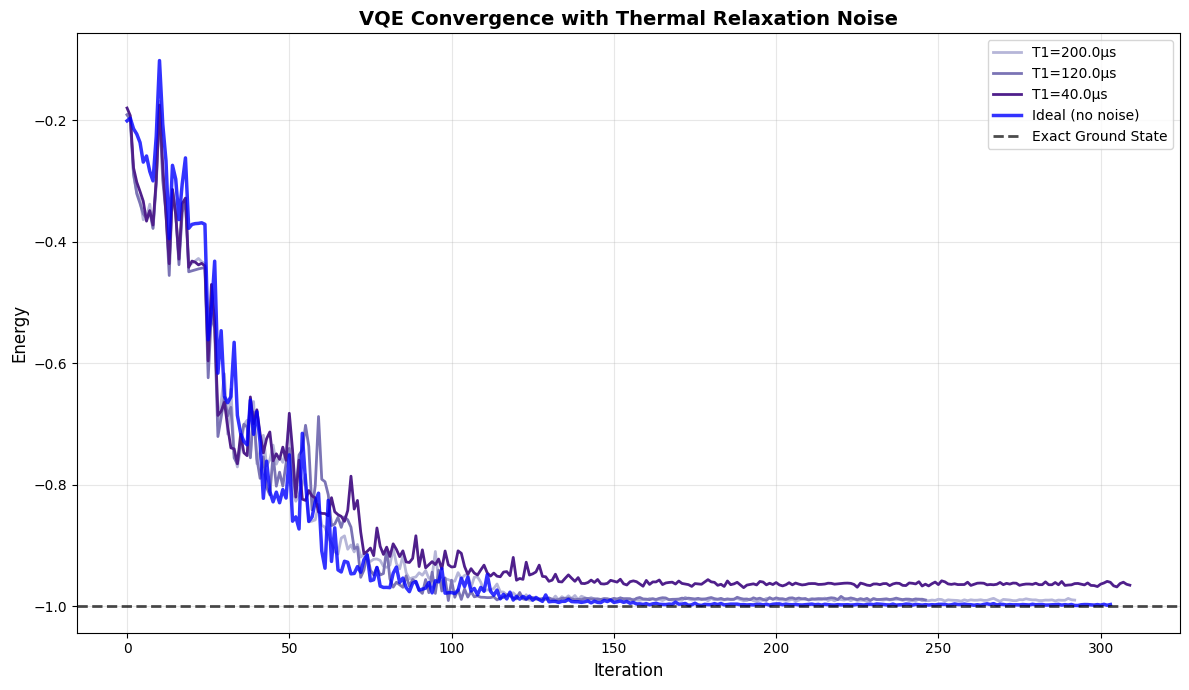

In [19]:
# Plot all thermal relaxation cases
plt.figure(figsize=(12, 7))

colors = plt.cm.Purples(np.linspace(0.4, 0.9, len(T1_values)))

for i, T1 in enumerate(T1_values):
    plt.plot(thermal_energy_histories[T1], linewidth=2,
             label=f'T1={T1*1e6:.1f}μs', color=colors[i])

plt.plot(ideal_energy_history, 'b-', linewidth=2.5, label='Ideal (no noise)', alpha=0.8)
plt.axhline(y=ground_state_energy, color='k', linestyle='--', linewidth=2,
            label='Exact Ground State', alpha=0.7)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('VQE Convergence with Thermal Relaxation Noise', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Let us zoom in the converged values

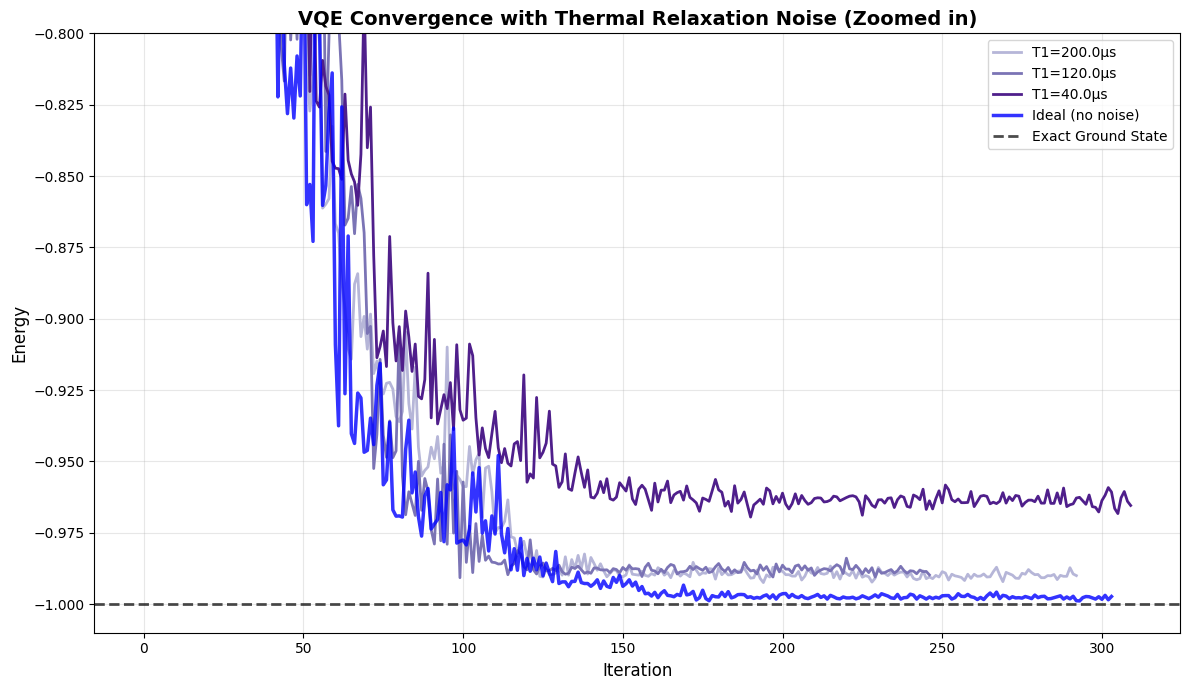

In [20]:
# Plot all thermal relaxation cases
plt.figure(figsize=(12, 7))

colors = plt.cm.Purples(np.linspace(0.4, 0.9, len(T1_values)))

for i, T1 in enumerate(T1_values):
    plt.plot(thermal_energy_histories[T1], linewidth=2,
             label=f'T1={T1*1e6:.1f}μs', color=colors[i])

plt.plot(ideal_energy_history, 'b-', linewidth=2.5, label='Ideal (no noise)', alpha=0.8)
plt.axhline(y=ground_state_energy, color='k', linestyle='--', linewidth=2,
            label='Exact Ground State', alpha=0.7)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('VQE Convergence with Thermal Relaxation Noise (Zoomed in)', fontsize=14, fontweight='bold')
plt.ylim(-1.01, -0.8)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 6: Combined Noise Effects

In realistic quantum devices, multiple noise sources act simultaneously. This section explores how different noise mechanisms combine to affect VQE performance. We compare four scenarios:

1. **Ideal**: No noise (baseline)
2. **Depolarizing Only**: Gate errors without thermal effects
3. **Thermal Only**: Coherence decay without gate errors
4. **Combined**: Both depolarizing and thermal noise

Understanding how noise sources compound is essential for predicting real device performance and designing effective error mitigation strategies.

In [21]:
# Combined noise parameters
prob_1q_combined = 0.003
prob_2q_combined = 0.02
t1_combined = 120e-6  # 120 microseconds
t2_combined = t1_combined

num_params = transpiled_ansatz.num_parameters

# Storage for all scenarios
scenarios = ['Ideal', 'Depolarizing Only', 'Thermal Only', 'Combined']
all_combined_histories = []

print("Running VQE with different noise scenarios...\n")

# Scenario 1: Ideal (no noise)
print("1. Ideal simulator (no noise)")
simulator_ideal = AerSimulator()
estimator_ideal = Estimator(mode=simulator_ideal)
estimator_ideal.options.seed_estimator = seed_estimator
energy_history_ideal = []

def cost_function_ideal(params):
    job = estimator_ideal.run([(transpiled_ansatz, transpiled_observable, params)])
    result = job.result()
    energy = result[0].data.evs
    energy_history_ideal.append(energy)
    return energy

np.random.seed(42)
initial_params = np.random.uniform(0, 2*np.pi, num_params)
result_ideal = minimize(cost_function_ideal, initial_params, method='COBYLA')
all_combined_histories.append(energy_history_ideal)
print(f"   Final energy: {result_ideal.fun:.6f}\n")

# Scenario 2: Depolarizing noise only
print("2. Depolarizing noise only")
noise_model_depol = NoiseModel()
error_1q_depol = depolarizing_error(prob_1q_combined, 1)
error_2q_depol = depolarizing_error(prob_2q_combined, 2)
noise_model_depol.add_all_qubit_quantum_error(error_1q_depol, ['x', 'sx'])
noise_model_depol.add_all_qubit_quantum_error(error_2q_depol, ['cz'])

simulator_depol = AerSimulator(noise_model=noise_model_depol)
estimator_depol = Estimator(mode=simulator_depol)
estimator_depol.options.seed_estimator = seed_estimator
energy_history_depol = []

def cost_function_depol(params):
    job = estimator_depol.run([(transpiled_ansatz, transpiled_observable, params)])
    result = job.result()
    energy = result[0].data.evs
    energy_history_depol.append(energy)
    return energy

np.random.seed(42)
initial_params = np.random.uniform(0, 2*np.pi, num_params)
result_depol = minimize(cost_function_depol, initial_params, method='COBYLA')
all_combined_histories.append(energy_history_depol)
print(f"   Final energy: {result_depol.fun:.6f}\n")

# Scenario 3: Thermal relaxation only
print("3. Thermal relaxation only")
noise_model_thermal = NoiseModel()
error_1q_thermal = thermal_relaxation_error(t1_combined, t2_combined, gate_time_1q)
error_2q_thermal = thermal_relaxation_error(t1_combined, t2_combined, gate_time_2q).tensor(
                   thermal_relaxation_error(t1_combined, t2_combined, gate_time_2q))
noise_model_thermal.add_all_qubit_quantum_error(error_1q_thermal, ['x', 'sx'])
noise_model_thermal.add_all_qubit_quantum_error(error_2q_thermal, ['cz'])

simulator_thermal = AerSimulator(noise_model=noise_model_thermal)
estimator_thermal = Estimator(mode=simulator_thermal)
estimator_thermal.options.seed_estimator = seed_estimator
energy_history_thermal = []

def cost_function_thermal(params):
    job = estimator_thermal.run([(transpiled_ansatz, transpiled_observable, params)])
    result = job.result()
    energy = result[0].data.evs
    energy_history_thermal.append(energy)
    return energy

np.random.seed(42)
initial_params = np.random.uniform(0, 2*np.pi, num_params)
result_thermal = minimize(cost_function_thermal, initial_params, method='COBYLA')
all_combined_histories.append(energy_history_thermal)
print(f"   Final energy: {result_thermal.fun:.6f}\n")

# Scenario 4: Combined noise
print("4. Combined noise (depolarizing + thermal)")
noise_model_combined = NoiseModel()

# Add depolarizing errors
error_1q_depol_comb = depolarizing_error(prob_1q_combined, 1)
error_2q_depol_comb = depolarizing_error(prob_2q_combined, 2)

# Add thermal relaxation errors
error_1q_thermal_comb = thermal_relaxation_error(t1_combined, t2_combined, gate_time_1q)
error_2q_thermal_comb = thermal_relaxation_error(t1_combined, t2_combined, gate_time_2q).tensor(
                        thermal_relaxation_error(t1_combined, t2_combined, gate_time_2q))

# Compose errors (depolarizing followed by thermal)
error_1q_combined_final = error_1q_depol_comb.compose(error_1q_thermal_comb)
error_2q_combined_final = error_2q_depol_comb.compose(error_2q_thermal_comb)

noise_model_combined.add_all_qubit_quantum_error(error_1q_combined_final, ['x', 'sx'])
noise_model_combined.add_all_qubit_quantum_error(error_2q_combined_final, ['cz'])

simulator_combined = AerSimulator(noise_model=noise_model_combined)
estimator_combined = Estimator(mode=simulator_combined)
estimator_combined.options.seed_estimator = seed_estimator
energy_history_combined = []

def cost_function_combined(params):
    job = estimator_combined.run([(transpiled_ansatz, transpiled_observable, params)])
    result = job.result()
    energy = result[0].data.evs
    energy_history_combined.append(energy)
    return energy

np.random.seed(42)
initial_params = np.random.uniform(0, 2*np.pi, num_params)
result_combined = minimize(cost_function_combined, initial_params, method='COBYLA')
all_combined_histories.append(energy_history_combined)
print(f"   Final energy: {result_combined.fun:.6f}\n")

print("All scenarios completed!")

Running VQE with different noise scenarios...

1. Ideal simulator (no noise)
   Final energy: -0.994059

2. Depolarizing noise only
   Final energy: -0.929606

3. Thermal relaxation only
   Final energy: -0.990885

4. Combined noise (depolarizing + thermal)
   Final energy: -0.917318

All scenarios completed!


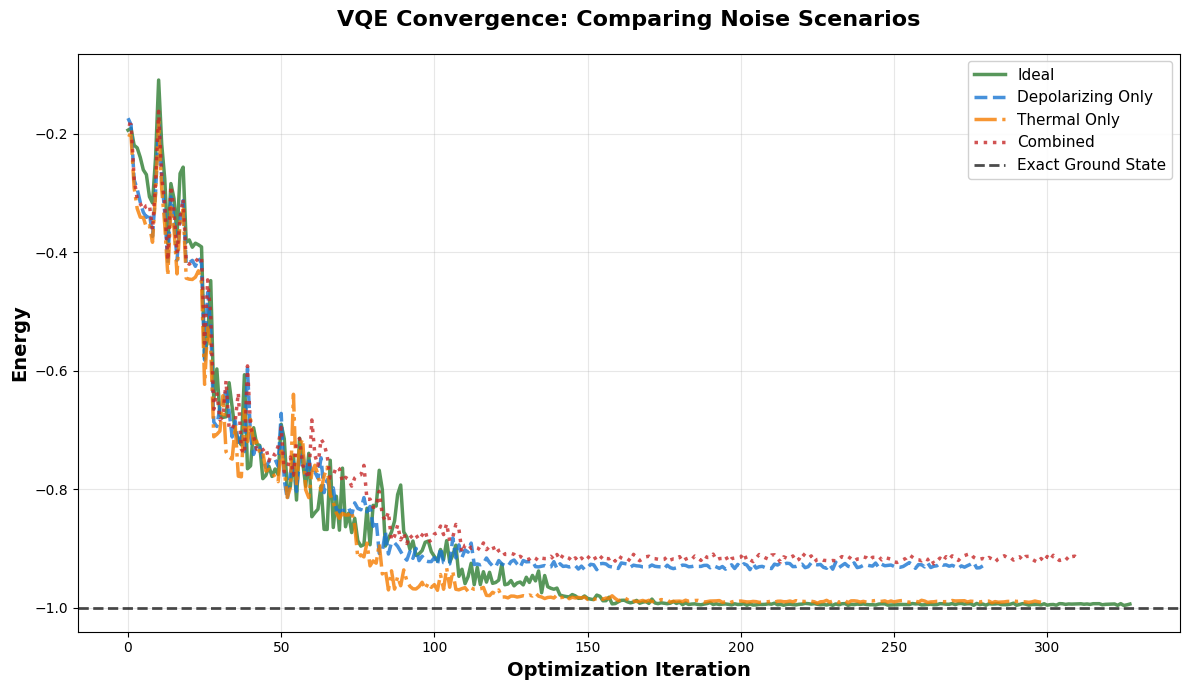


SUMMARY: Final Energy Values
Exact Ground State Energy:     -1.000000
Ideal (No Noise):              -0.994059
Depolarizing Only:             -0.929606
Thermal Only:                  -0.990885
Combined Noise:                -0.917318

Error from exact (Ideal):      0.005941
Error from exact (Depolarizing): 0.070394
Error from exact (Thermal):    0.009115
Error from exact (Combined):   0.082682


In [31]:
# Visualization: Compare all noise scenarios
plt.figure(figsize=(12, 7))

colors = ['#2E7D32', '#1976D2', '#F57C00', '#C62828']
linestyles = ['-', '--', '-.', ':']

for i, (scenario, history) in enumerate(zip(scenarios, all_combined_histories)):
    plt.plot(history, label=scenario, color=colors[i], 
             linestyle=linestyles[i], linewidth=2.5, alpha=0.8)

plt.axhline(y=ground_state_energy, color='black', linestyle='--', 
            linewidth=2, label='Exact Ground State', alpha=0.7)

plt.xlabel('Optimization Iteration', fontsize=14, fontweight='bold')
plt.ylabel('Energy', fontsize=14, fontweight='bold')
plt.title('VQE Convergence: Comparing Noise Scenarios', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY: Final Energy Values")
print("="*60)
print(f"Exact Ground State Energy:     {ground_state_energy:.6f}")
print(f"Ideal (No Noise):              {result_ideal.fun:.6f}")
print(f"Depolarizing Only:             {result_depol.fun:.6f}")
print(f"Thermal Only:                  {result_thermal.fun:.6f}")
print(f"Combined Noise:                {result_combined.fun:.6f}")
print("="*60)
print(f"\nError from exact (Ideal):      {abs(result_ideal.fun - ground_state_energy):.6f}")
print(f"Error from exact (Depolarizing): {abs(result_depol.fun - ground_state_energy):.6f}")
print(f"Error from exact (Thermal):    {abs(result_thermal.fun - ground_state_energy):.6f}")
print(f"Error from exact (Combined):   {abs(result_combined.fun - ground_state_energy):.6f}")
print("="*60)

Let us zoom in the converged region

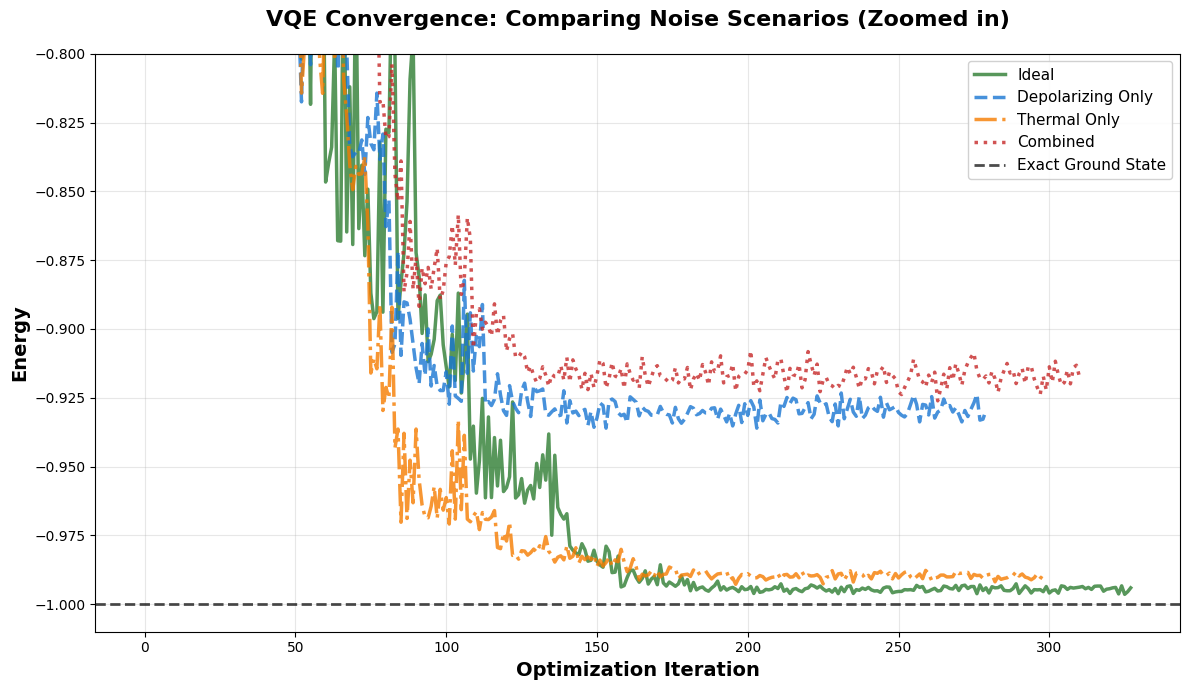

In [32]:
# Visualization: Compare all noise scenarios
plt.figure(figsize=(12, 7))

colors = ['#2E7D32', '#1976D2', '#F57C00', '#C62828']
linestyles = ['-', '--', '-.', ':']

for i, (scenario, history) in enumerate(zip(scenarios, all_combined_histories)):
    plt.plot(history, label=scenario, color=colors[i], 
             linestyle=linestyles[i], linewidth=2.5, alpha=0.8)

plt.axhline(y=ground_state_energy, color='black', linestyle='--', 
            linewidth=2, label='Exact Ground State', alpha=0.7)

plt.xlabel('Optimization Iteration', fontsize=14, fontweight='bold')
plt.ylabel('Energy', fontsize=14, fontweight='bold')
plt.title('VQE Convergence: Comparing Noise Scenarios (Zoomed in)', fontsize=16, fontweight='bold', pad=20)
plt.ylim(-1.01,-0.8)
plt.legend(fontsize=11, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### How do we mitigate the effect of depolarizing noise and thermal relaxation noise combined?

We need some way to understand how the effect of noise increases with increasing error probability. In simulation we could manually increase the error probability, but we can't do the same in real quantum devices. Can you think of a way to increase the effect of noise?

> What if we increase the number of gates without changing the functionality of the circuit?

In [24]:
def fold_local_circuit(circuit: QuantumCircuit, scale_factor: int) -> QuantumCircuit:
    """Performs Gate Folding at the level of individual circuit instructions."""

    if scale_factor % 2 == 0:
        raise ValueError("scale must be an odd positive integer (1, 3, 5, ...)")

    # We define the number of times we are going to "fold" each instruction
    n_repeat = (scale_factor - 1) // 2
    qc_folded = QuantumCircuit(circuit.qubits, circuit.clbits)

    if scale_factor == 1:
        return circuit
    else:
        for instruction in circuit.data:
            if instruction.operation.name not in ["measure", "barrier"]:
                qc_folded.append(instruction.operation, instruction.qubits)

                # Apply folding: (G · G^† ) ^ n
                for _ in range(n_repeat):
                    qc_folded.append(instruction.operation, instruction.qubits)

                    qc_folded.append(instruction.operation.inverse(), instruction.qubits)
            else:
                qc_folded.append(instruction)

    return qc_folded

Scale factor: 1


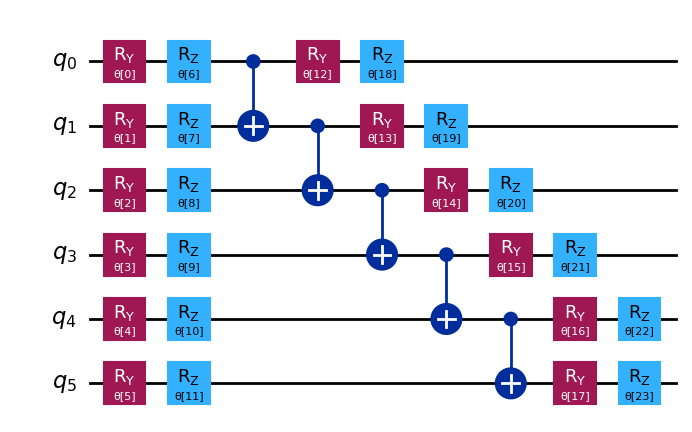


Scale factor: 3


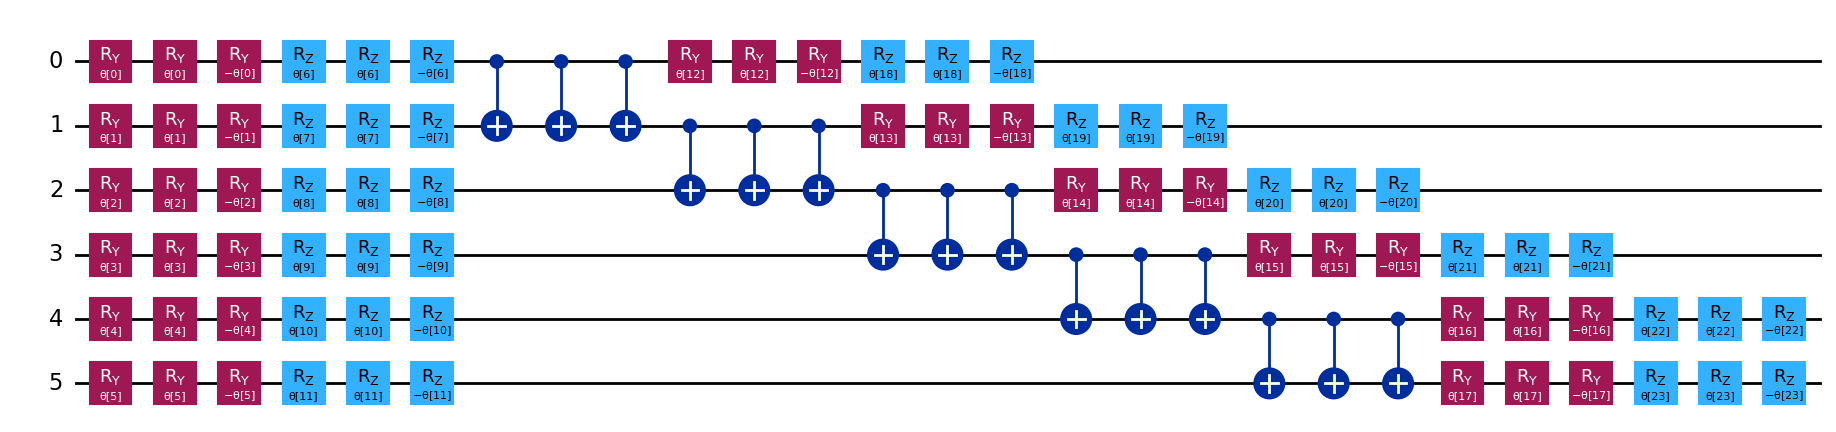


Scale factor: 5


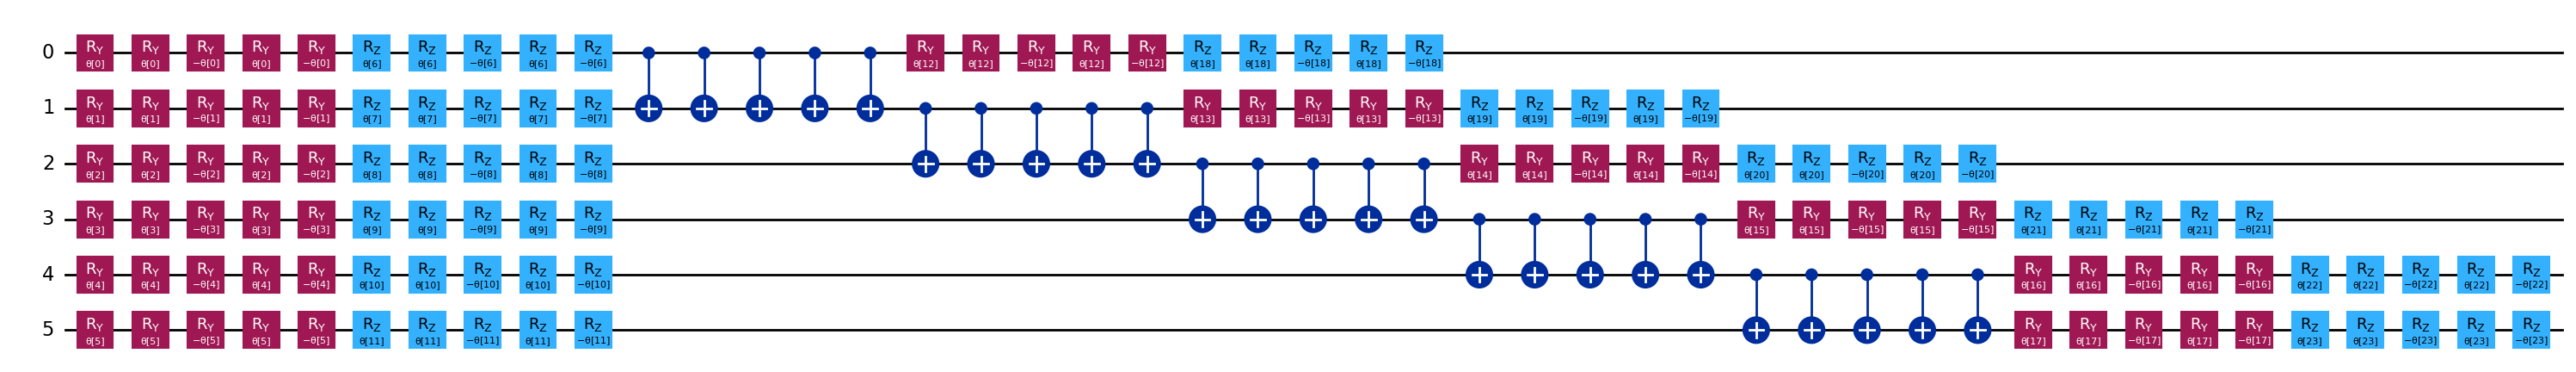


Scale factor: 7


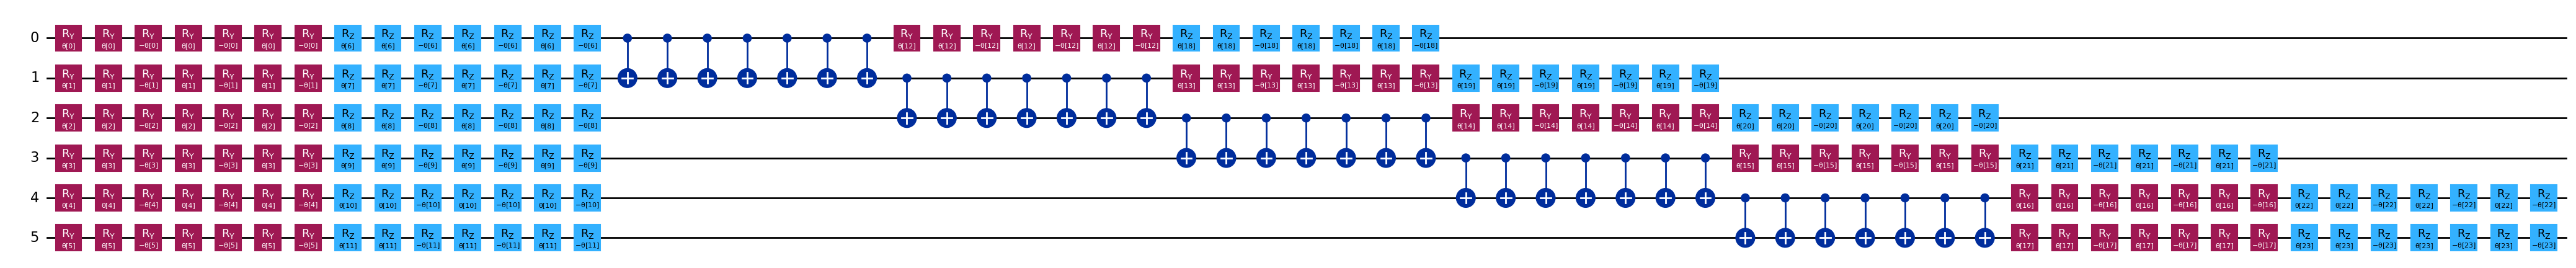


Scale factor: 9


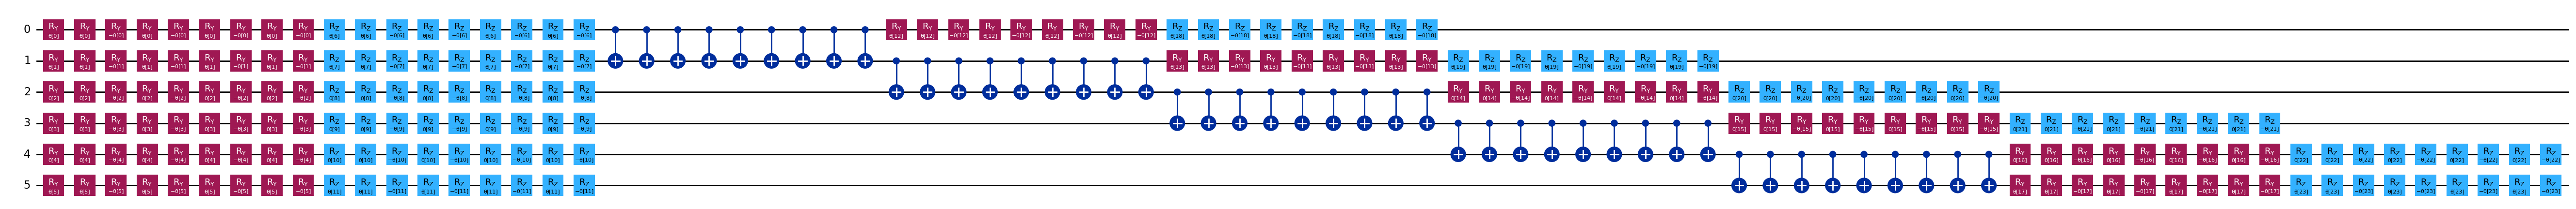

In [25]:
scaling_factors = [1, 3, 5, 7,  9]
folded_circuits = [fold_local_circuit(ansatz, scale_factor)
                   for scale_factor in scaling_factors]

for idx in range(len(scaling_factors)):
    print(f"Scale factor: {scaling_factors[idx]}")
    display(folded_circuits[idx].draw('mpl', fold=-1))
    print()

Let us use the final parameter of the converged circuit, and then execute the three folded circuits with the combined noise.

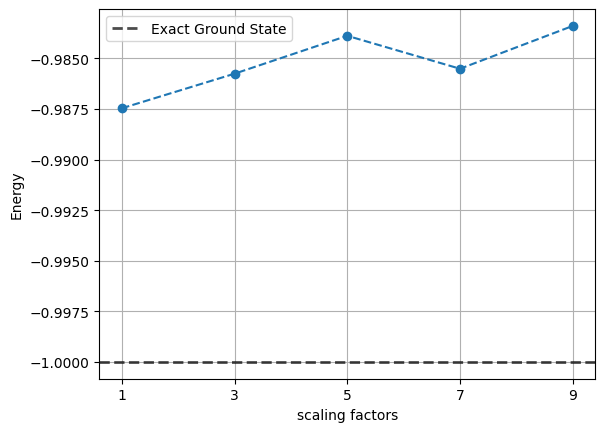

In [33]:
estimator_combined.skip_transpilation = True
job = estimator_depol.run([(folded_circuits[i], transpiled_observable, result_depol.x)
                            for i in range(len(folded_circuits))])
expvals = [job.result()[i].data.evs for i in range(len(folded_circuits))]

plt.plot(scaling_factors, expvals, 'o--')
plt.xlabel("scaling factors")
plt.ylabel("Energy")
plt.grid()
plt.axhline(y=ground_state_energy, color='black', linestyle='--', 
            linewidth=2, label='Exact Ground State', alpha=0.7)
plt.xticks(scaling_factors)
plt.legend()
plt.show() 

As expected the noise of the computation increases with increasing scaling factor. Now, we can fit a curve through these values, and extrapolate it back to the zero noise limit. 

> But the expectation values seem to jump around a lot, and is not a monotonic curve with increasing scaling factor. This is because different noise (depolarizing, thermal relaxation) acts in a different way, and have different error rates. When multiple types of noise with different rate act on the circuit, we cannot expect that folding will will provide a monotonic outcome.

> Pauli twirling comes to rescue here! In Pauli twirling, instead of running multiple identical circuits, we run multiple functionally identical, structurally different circuits, and average over them. Each clifford gate $C$ is sandwitched between two Paulis $P$ and $P'$ such that $C = PCP'$. The Paulis $P$ are randomly sampled from the Pauli group for each shot. This way the effect of different noise are averaged into a single Stochastic Pauli Noise model.

In [28]:
def linear_model(x, a, b):
    return a * x + b

def quadratic_model(x, a, b, c):
    return a * x**2 + b * x + c

def exponential_model(x, a, b, c):
    return a * np.exp(-b * x) + c

def zne_method(method="linear", xdata=[], ydata=[]):

    if method == "linear":
        popt, _ = curve_fit(linear_model, xdata, ydata)
        zero_val = linear_model(0, *popt)
        fit_fn = linear_model
    elif method == "quadratic":
        popt, _ = curve_fit(quadratic_model, xdata, ydata)
        zero_val = quadratic_model(0, *popt)
        fit_fn = quadratic_model
    elif method == "exponential":
        popt, _ = curve_fit(exponential_model, xdata, ydata, p0=(1, 0.1, 0), maxfev=5000)
        zero_val = exponential_model(0, *popt)
        fit_fn = exponential_model
    else:
        raise ValueError(f"Unknown method '{method}'. Use 'linear', 'quadratic', or 'exponential'.")

    return zero_val, ydata, popt, fit_fn

In [34]:
methods = ["linear", "quadratic", "exponential"]
extrapolated_expvals = []

for method in methods:
    print(f"\n Extrapolation Method: {method.upper()}")

    # Perform the extrapolation
    zero_val, fitted_vals, fit_params, fit_fn = zne_method(method=method, xdata=scaling_factors, ydata=expvals)
    extrapolated_expvals.append(zero_val)
    
    # Print the extrapolated expectation value
    print(f"⟨Z⟩ (ZNE Estimate): {zero_val}")


 Extrapolation Method: LINEAR
⟨Z⟩ (ZNE Estimate): -0.9873006184895825

 Extrapolation Method: QUADRATIC
⟨Z⟩ (ZNE Estimate): -0.9881158737909204

 Extrapolation Method: EXPONENTIAL
⟨Z⟩ (ZNE Estimate): -0.9890717237122865


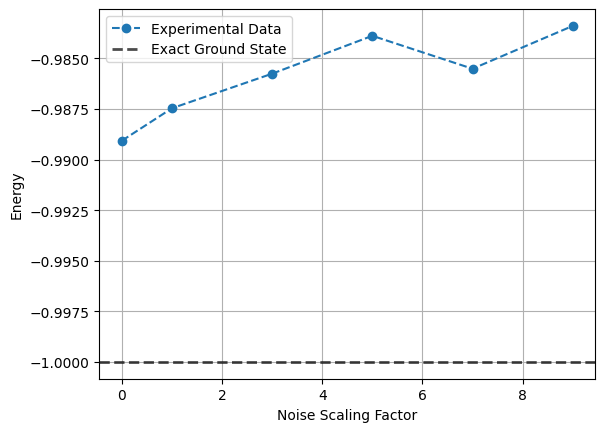

In [35]:
xdata = [0] + scaling_factors
ydata = [extrapolated_expvals[-1]] + expvals
plt.plot(xdata, ydata, "o--", label="Experimental Data")
plt.axhline(y=ground_state_energy, color='black', linestyle='--', 
            linewidth=2, label='Exact Ground State', alpha=0.7)
plt.xlabel("Noise Scaling Factor")
plt.ylabel("Energy")
plt.legend()
plt.grid()
plt.show()

### Key Observations

The comparison reveals several important insights:

1. **Noise Compounding**: When multiple noise sources are present, their effects compound non-linearly. The combined noise scenario typically shows worse performance than either individual noise source alone.

2. **Dominant Noise Source**: Depending on the specific parameters, one noise type may dominate. In this example, depolarizing noise on two-qubit gates often has a larger impact than thermal relaxation for moderate T₁ values.

3. **Optimization Trajectory**: Different noise types affect the optimization landscape differently.

4. **Practical Implications**: Real quantum devices must contend with all these noise sources simultaneously. This underscores the importance of:
   - Improving gate fidelities (reducing depolarizing errors)
   - Extending coherence times (increasing T₁ and T₂)
   - Minimizing circuit depth and gate count
   - Implementing error mitigation techniques

## Section 7: Execute on hardware with error mitigation

Now we shall execute on IBM Quantum hardware with error mitigation. Error mitigation can be applied to quantum workloads via `resilience_level`.

| Resilience level | Description | Technique |
| -------- | -------- | -------- |
| 0    | No mitigation   | None   |
| 1 (default)    | Measurement error mitigation   | TREX   |
| 2    | Combined error mitigation   | TREX + ZNE + Gate twirling   |

In [ ]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, )
print(f'Backend to be used: {backend}')

Backend to be used: <IBMBackend('ibm_fez')>


Now we need to transpile our circuit to the hardware

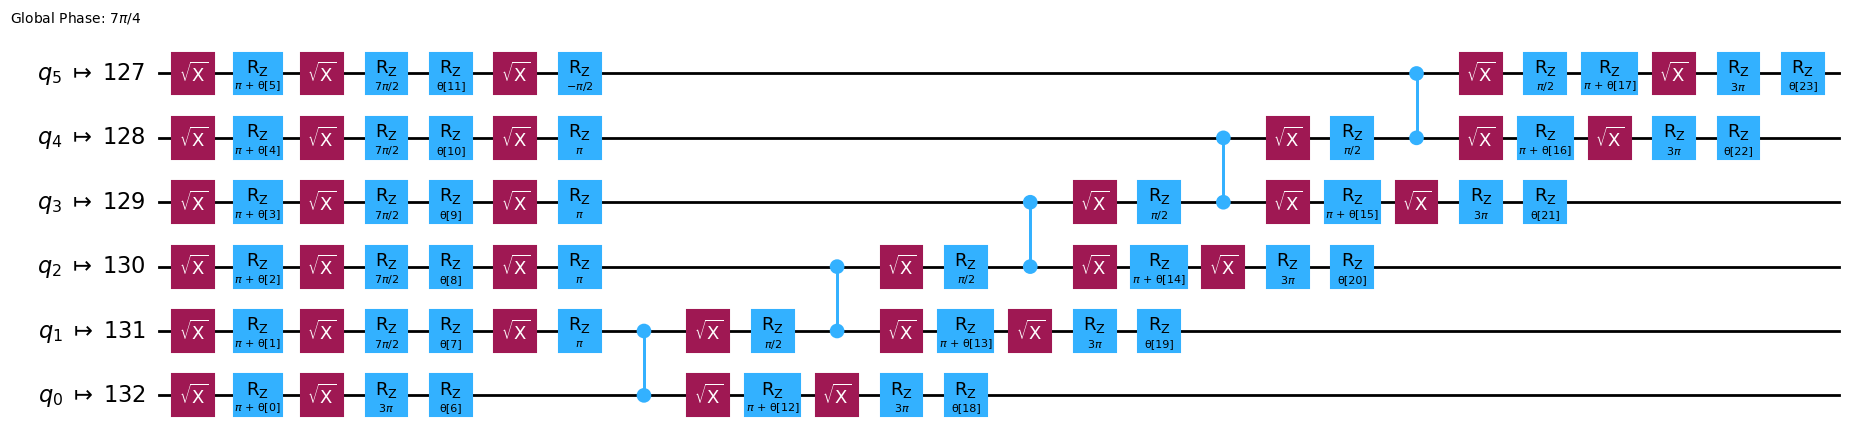

In [91]:
pm_hw = generate_preset_pass_manager(optimization_level=3, backend=backend)
isa_ansatz = pm_hw.run(ansatz)
isa_ansatz.assign_parameters(result_ideal.x)
isa_ansatz.draw('mpl', fold=-1)

We also need to apply the layout information to the observable

In [93]:
isa_observable = observable.apply_layout(isa_ansatz.layout)
isa_observable

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[0.

Now let us run the circuits with different resilience levels

In [100]:
from qiskit_ibm_runtime import Batch
job_ids = []
batch_id = None

with Batch(backend=backend) as batch:
    for resilience_level in range(3):
        estimator_hw = Estimator(mode=batch)
        estimator_hw.options.resilience_level = resilience_level
        job = estimator_hw.run([(isa_ansatz, isa_observable, result_ideal.x)])
        job_id = job.job_id()
        job_ids.append(job_id)

batch_id = batch.session_id

print('Job IDs: ', job_ids)
print('Batch ID: ', batch_id)


Job IDs:  ['d8rt5f6gbcrc73f4v1ng', 'd8rt5fmkodhs7384rcng', 'd8rt5g6gbcrc73f4v1p0']
Batch ID:  a206793f-ae1a-4a6a-9937-bd35ab875ea1


In [102]:
jobs = [service.job(job_ids[i]) for i in range(3)]
expvals = [job.result()[0].data.evs for job in jobs]

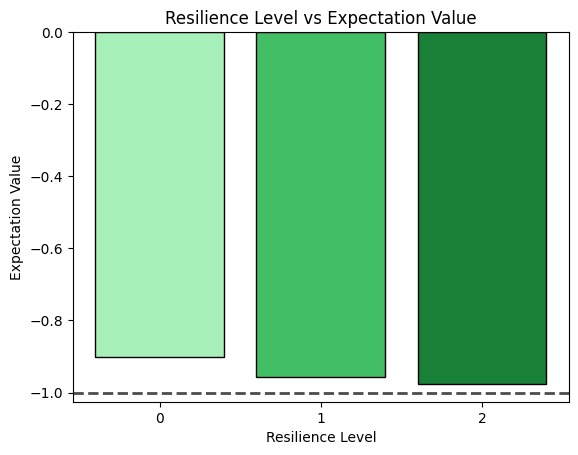

In [110]:
plt.bar(range(3), expvals, color=['#a7f0ba', '#42be65', '#198038'], edgecolor ='black')
plt.axhline(y=ground_state_energy, color='black', linestyle='--', 
            linewidth=2, label='Exact Ground State', alpha=0.7)
plt.xlabel('Resilience Level')
plt.ylabel('Expectation Value')
plt.title('Resilience Level vs Expectation Value')
plt.xticks(range(3))
plt.show()

## Summary and Conclusions

### Key Findings

Through this notebook, you have explored three fundamental types of quantum noise and their impact on quantum algorithm performance:

1. **Readout Error**: Even small measurement errors (1-3%) can significantly bias energy estimates. Readout errors are particularly problematic because they directly corrupt the final measurement outcomes, leading to systematic errors in expectation values.

2. **Depolarizing Noise**: Gate errors accumulate throughout circuit execution. Two-qubit gates, with error rates an order of magnitude higher than single-qubit gates, are the dominant source of depolarizing noise. As circuits become deeper, these errors compound, degrading the quality of the quantum state.

3. **Thermal Relaxation**: Quantum coherence decays exponentially with time. Longer circuits are more susceptible to thermal relaxation, as qubits have more time to relax to their ground state or lose phase coherence. This sets a fundamental limit on circuit depth for near-term quantum devices.

4. **Error Mitigation**: Understanding these noise sources is crucial for developing error mitigation strategies. Error mitigation is crucial to run quantum circuits on near-term devices.

### References

1. Qiskit Documentation: [Building Noise Models](https://quantum.cloud.ibm.com/docs/en/guides/build-noise-models)

2. Qiskit API Reference: [EfficientSU2 Circuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.EfficientSU2)

3. Error mitigation pipeline: [Majumdar R. et al. Best Practices for Quantum Error Mitigation with Digital Zero-Noise Extrapolation](https://ieeexplore.ieee.org/abstract/document/10313813?casa_token=TJYmQkA9o10AAAAA:T0QNPfcVEP43ZbebvUfkMOSLoAGipleE7tqDXOfDSYUGBCDcQST5MBClQ0j7TTxrGsz_VddIYLY)